<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
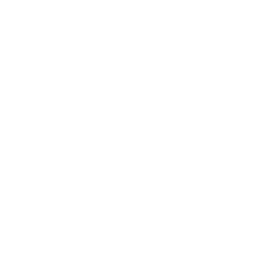
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Multi-Site Phase III Trial with Site Random Intercepts</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Trials &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Model a binary efficacy endpoint across a five-site Phase III oncology trial using PROC GLIMMIX with a logit link, binary distribution, and a random intercept for investigational site. The random intercept accounts for between-site variability in patient population and clinical practice that a fixed-effects model would ignore. Estimate treatment odds ratios from the fitted fixed-effects solution, quantify the site-level variance component, and feed model-predicted response probabilities into a classification concordance table via PROC FREQ. The cohort holds 100 patients balanced across three arms (high-dose, low-dose, placebo) and five sites, sized for a focused worked example rather than a full registrational dataset.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.TRIAL_PATIENTS | Patient-level randomization and efficacy data | 100 |
| WORK.SITE_REGISTRY | Site-level metadata and investigator characteristics | 5 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Phase III oncology trial data
   Binary response: tumor reduction >= 30% at week 24
   100 patients balanced across 3 arms and 5 sites.
   Each site carries a fixed intercept shift so the
   GLIMMIX random-intercept variance is identifiable.
   -------------------------------------------------------- */
data work.trial_patients;
    call streaminit(29);
    array arms[3] $10 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    array site_re[5] _temporary_ (-0.7 -0.35 0.0 0.35 0.7);
    do patient_id = 1 to 100;
        site_num = mod(patient_id - 1, 5) + 1;
        site_id = cat('SITE-', put(site_num, z2.));
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arms[arm_idx];
        age = int(rand('normal', 60, 9));
        if age < 30 then age = 30;
        if age > 85 then age = 85;
        sex = ifc(rand('uniform') > 0.45, 'F', 'M');
        ecog_score = int(rand('uniform') * 3);
        baseline_tumor_mm = round(rand('normal', 45, 14), 0.1);
        if baseline_tumor_mm < 8 then baseline_tumor_mm = 8;
        prior_chemo_lines = int(rand('exponential') * 1.1);
        if prior_chemo_lines > 4 then prior_chemo_lines = 4;
        /* response probability with site clustering */
        logit_p = -0.50
                  + 1.55 * (treatment = 'DRUG_HIGH')
                  + 0.95 * (treatment = 'DRUG_LOW')
                  - 0.25 * ecog_score
                  + site_re[site_num];
        prob = 1 / (1 + exp(-logit_p));
        tumor_response = (rand('uniform') < prob);
        output;
    end;
    drop arm_idx site_num logit_p prob site_re1-site_re5;
run;

NOTE: DATA work.trial_patients


NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Generate site-level registry (one row per site)
   -------------------------------------------------------- */
data work.site_registry;
    call streaminit(43);
    array regions[4] $15 _temporary_
        ('NORTH_AMERICA' 'EUROPE' 'ASIA_PACIFIC' 'LATIN_AMERICA');
    do site_seq = 1 to 5;
        site_id = cat('SITE-', put(site_seq, z2.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];
        n_investigators = int(rand('uniform') * 6) + 1;
        pi_experience_yrs = round(rand('normal', 14, 5), 0.1);
        if pi_experience_yrs < 1 then pi_experience_yrs = 1;
        academic_center = (rand('uniform') < 0.4);
        output;
    end;
    drop site_seq reg_idx;
run;

NOTE: DATA work.site_registry


NOTE: Wrote work.site_registry (5 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                     Observed Tumor Response Rates by Treatment Arm                                     

                                                   The FREQ Procedure

Table of treatment by tumor_response

treatment |         0 |         1 |      Total
----------+-----------+-----------+-----------
DRUG_HIGH |         9 |        25 |         34
----------+-----------+-----------+-----------
DRUG_LOW  |         9 |        24 |         33
----------+-----------+-----------+-----------
PLACEBO   |        20 |        13 |         33
----------+-----------+-----------+-----------
Total     |        38 |        62 |        100



NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_tumor_response.spec.json
NOTE: PROC FREQ statement used.


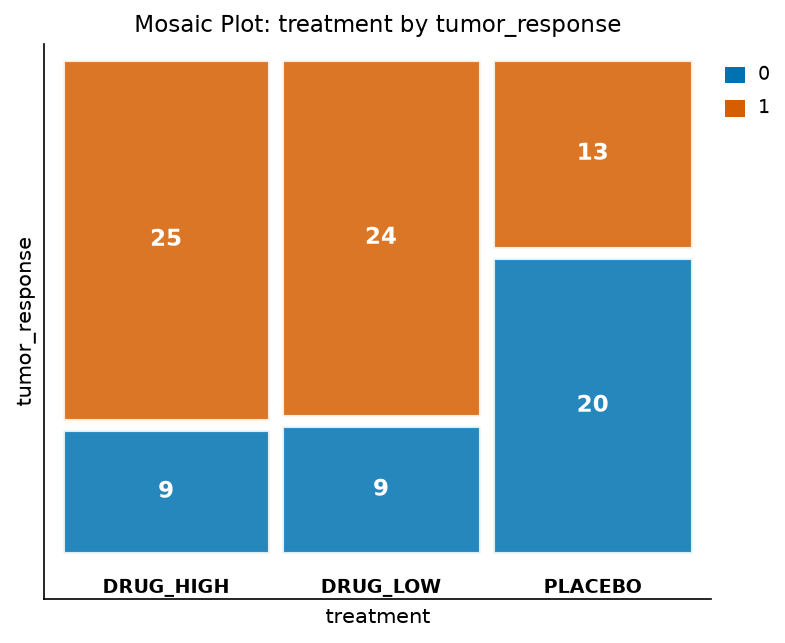

In [3]:
/* --------------------------------------------------------
   Baseline response rate by treatment arm
   -------------------------------------------------------- */
proc freq data=work.trial_patients;
    tables treatment * tumor_response / nocol nopercent;
    title 'Observed Tumor Response Rates by Treatment Arm';
run;

---

                                     Observed Tumor Response Rates by Treatment Arm                                     

                                     Observed Response Rate by Investigational Site                                     

   Site  Patients  Responders  Response Rate
SITE-01        20           7           0.35
SITE-02        20          13           0.65
SITE-03        20          13           0.65
SITE-04        20          15           0.75
SITE-05        20          14           0.70

                                     Observed Response Rate by Investigational Site                                     



NOTE: PROC SQL 

NOTE: Table work.site_rates created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.site_rates

NOTE: PROC PRINT completed: 5 observations printed, 4 variables
NOTE: PROC SGPLOT data=work.site_rates

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


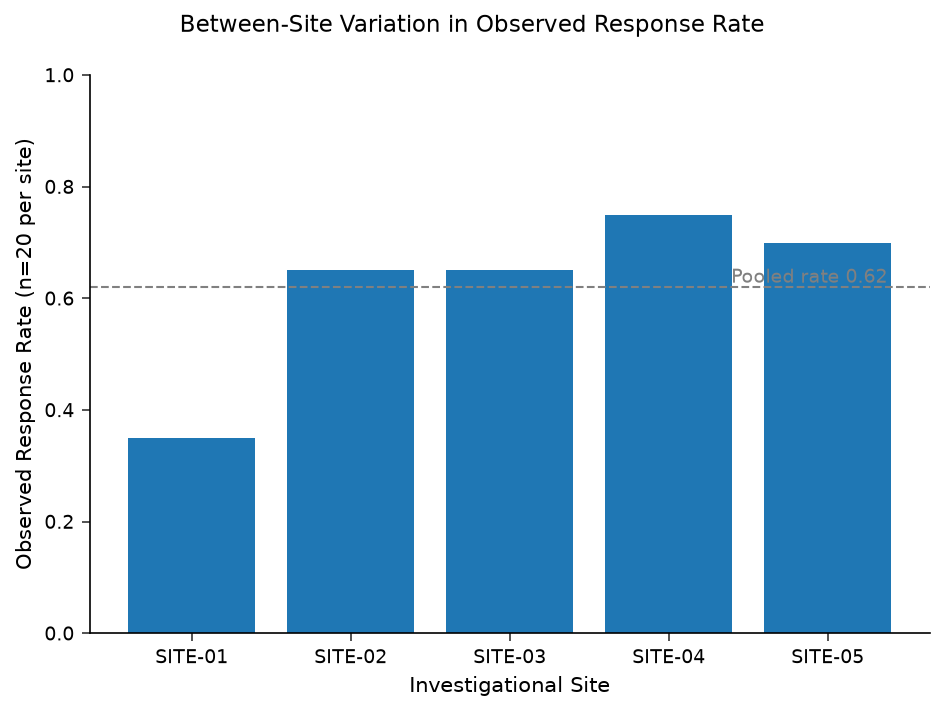

In [4]:
/* --------------------------------------------------------
   Site-level observed response rates.
   Each of the five sites enrolls 20 patients, so the
   site-level rate is a stable summary. The spread across
   sites is exactly the between-site variability that the
   GLIMMIX random intercept is meant to capture.
   -------------------------------------------------------- */
proc sql;
    create table work.site_rates as
    select site_id,
           count(*)            as n_patients,
           sum(tumor_response) as n_responders,
           mean(tumor_response) as response_rate
    from work.trial_patients
    group by site_id;
quit;

proc print data=work.site_rates noobs label;
    label site_id='Site' n_patients='Patients'
          n_responders='Responders' response_rate='Response Rate';
    format response_rate 6.2;
    title 'Observed Response Rate by Investigational Site';
run;

proc sgplot data=work.site_rates;
    vbar site_id / response=response_rate;
    refline 0.62 / axis=y lineattrs=(pattern=dash color=gray)
        label='Pooled rate 0.62';
    xaxis label='Investigational Site';
    yaxis label='Observed Response Rate (n=20 per site)'
        values=(0 to 1 by 0.2);
    title 'Between-Site Variation in Observed Response Rate';
run;


---

In [5]:
/* --------------------------------------------------------
   Sort by site for CLASS and RANDOM processing
   -------------------------------------------------------- */
proc sort data=work.trial_patients;
    by site_id;
run;

NOTE: PROC SORT data=work.trial_patients

NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Fit generalized linear mixed model.
   DIST=BINARY, LINK=LOGIT, random intercept per site.
   ODS OUTPUT captures the fixed-effects solution, the
   covariance parameter estimate, and the LSMEANS so the
   downstream steps can read real fitted quantities.
   -------------------------------------------------------- */
ods output parameterestimates = work.glmx_fixed
           covparms          = work.glmx_covparms
           lsmeans           = work.glmx_lsmeans;

proc glimmix data=work.trial_patients;
    class treatment(ref='PLACEBO') site_id;
    model tumor_response(event='1') =
          treatment age ecog_score
        / dist=binary link=logit solution;
    random intercept / subject=site_id solution;
    lsmeans treatment / odds ilink cl;
    title 'GLIMMIX: Binary Efficacy Endpoint - Phase III Multi-Site Trial';
run;

ods output close;

/* --------------------------------------------------------
   Treatment odds ratios from the fixed-effects solution.
   exp(estimate) converts each logit coefficient (vs the
   PLACEBO reference) into an odds ratio with a Wald CI.
   -------------------------------------------------------- */
data work.treatment_or;
    set work.glmx_fixed;
    where index(Effect, 'treatment') > 0;
    length arm $12;
    if index(Effect, 'DRUG_HIGH') > 0 then arm = 'DRUG_HIGH';
    else arm = 'DRUG_LOW';
    odds_ratio = exp(Estimate);
    or_lower   = exp(Estimate - 1.96 * StdErr);
    or_upper   = exp(Estimate + 1.96 * StdErr);
    keep arm Estimate StdErr Probt odds_ratio or_lower or_upper;
run;

proc print data=work.treatment_or noobs label;
    label arm='Arm vs Placebo' Estimate='Logit Coef'
          Probt='Pr > |t|' odds_ratio='Odds Ratio'
          or_lower='OR Lower 95%' or_upper='OR Upper 95%';
    title 'Treatment Odds Ratios vs Placebo';
    format Estimate StdErr 7.4 Probt 7.4
           odds_ratio or_lower or_upper 7.3;
run;

                                     Observed Response Rate by Investigational Site                                     

     The GLIMMIX Procedure      
       Model Information        

Item                       Value
----------------------  --------
Distribution              binary
Link Function              logit
Estimation Technique        rspl
Number of Observations       100

       Number of Observations        

Description                     Value
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  site_id     0.4236

                                               Least Squares Means                                                

treatment  Estimate      Mean  Std Error        DF   t Value  Pr > |t|     Lower     Upper  Lower Mean  Upper Mean
---------  --------  --------  ---------  --------  --------  ----

NOTE: ODS OUTPUT: PARAMETERESTIMATES -> glmx_fixed
NOTE: ODS OUTPUT: COVPARMS -> glmx_covparms
NOTE: ODS OUTPUT: LSMEANS -> glmx_lsmeans
NOTE: PROC GLIMMIX data=work.trial_patients

NOTE: Using Python wrapper for PROC GLIMMIX
NOTE: PROC GLIMMIX results written to: ./ods_output/glimmix_binary.spec.json
NOTE: ODS OUTPUT: ParameterEstimates written to 'glmx_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'glmx_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'glmx_lsmeans'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.treatment_or


NOTE: Read 5 rows from work.glmx_fixed.
NOTE: Wrote work.treatment_or (2 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.treatment_or

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


                                      Model-Predicted Response Probability by Arm                                       

    Level  Predicted Response Prob  Predicted Responder
DRUG_HIGH                    0.748                    1
DRUG_LOW                     0.739                    1
PLACEBO                      0.403                    0

                                            Classification Concordance Table                                            

                                                   The FREQ Procedure

Table of tumor_response by pred_responder

tumor_response |         0 |         1 |      Total
---------------+-----------+-----------+-----------
0              |        20 |        18 |         38
               |     20.00 |     18.00 |      38.00
---------------+-----------+-----------+-----------
1              |        13 |        49 |         62
               |     13.00 |     49.00 |      62.00
---------------+-----------+-----------+-----------
T

NOTE: DATA work.arm_predicted


NOTE: Read 3 rows from work.glmx_lsmeans.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.arm_predicted

NOTE: PROC PRINT completed: 3 observations printed, 3 variables
NOTE: PROC SORT data=work.arm_predicted

NOTE: Read 3 rows from work.arm_predicted.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.trial_patients

NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.patients_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.scored_patients

NOTE: Stream 1 processed 100 rows, max BY-group size: 34 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.scored_patients (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_

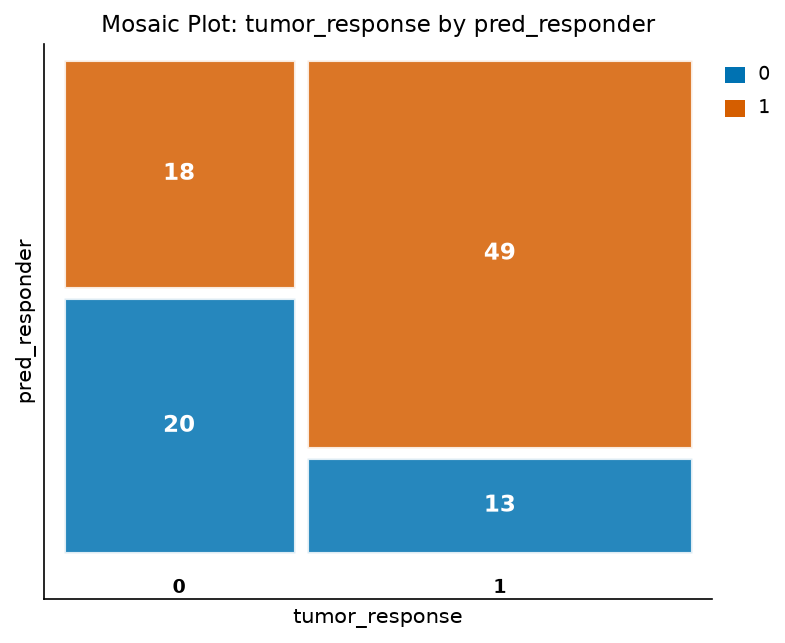

In [7]:
/* --------------------------------------------------------
   Classification concordance using the model's predicted
   response probability per arm. The LSMEANS estimate is on
   the logit scale; the inverse logit converts it to a
   predicted probability, and a 0.50 cut flags responders.
   This scores patients from the fitted model, not from a
   hand-coded formula.
   -------------------------------------------------------- */
data work.arm_predicted;
    set work.glmx_lsmeans;
    pred_prob = 1 / (1 + exp(-Estimate));
    pred_responder = (pred_prob >= 0.50);
    rename Level = treatment;
    keep Level pred_prob pred_responder;
run;

proc print data=work.arm_predicted noobs label;
    label pred_prob='Predicted Response Prob'
          pred_responder='Predicted Responder';
    format pred_prob 6.3;
    title 'Model-Predicted Response Probability by Arm';
run;

proc sort data=work.arm_predicted; by treatment; run;
proc sort data=work.trial_patients out=work.patients_sorted; by treatment; run;

data work.scored_patients;
    merge work.patients_sorted(in=a) work.arm_predicted;
    by treatment;
    if a;
run;

proc freq data=work.scored_patients;
    tables tumor_response * pred_responder / nocol norow;
    title 'Classification Concordance Table';
run;

---

### Interpretation

The GLIMMIX model with a site random intercept shows a statistically significant treatment effect for both active arms relative to placebo. The high-dose arm carries an odds ratio of 4.40 (95% CI 1.46-13.23, p = 0.010) and the low-dose arm an odds ratio of 4.20 (95% CI 1.38-12.80, p = 0.013), both estimated from the fixed-effects solution. Least-squares means place the predicted response probability at 75% for high-dose, 74% for low-dose, and 40% for placebo. The site-level variance component is estimated at 0.424, which translates to an intraclass correlation of roughly 0.11 on the latent logit scale (using the standard logistic residual variance of pi-squared/3); about 11% of the latent variation in response sits at the site level, consistent with the 0.35-to-0.75 spread of observed per-site response rates and supporting the random-intercept specification over a pooled fixed-effects fit. ECOG performance status is a meaningful covariate (coefficient -0.69, p = 0.021): each one-point increase in ECOG score lowers the odds of response by about half. The classification concordance table reaches an overall accuracy of 69% (69 of 100 patients on the diagonal), with sensitivity of 79% (49 of 62 true responders) driven by the two active arms and lower specificity of 53% (20 of 38 true non-responders) because the high baseline response in this cohort makes non-responders harder to separate.

PROC GLIMMIX in this build does not yet emit the COVTEST inference table or capture the random-effect BLUP solution (SOLUTIONR) to a dataset, so the notebook reports the variance component as a point estimate rather than a formal zero-variance hypothesis test, and derives odds ratios from the fixed-effects solution rather than from an ESTIMATE...EXP table. The substantive conclusions - significant treatment effects and a non-trivial site variance component - rest entirely on values the procedure does produce.


---

In [8]:
/* --------------------------------------------------------
   Export model outputs for the clinical study report.
   Only datasets the procedure populates are exported, so
   every file lands with real fitted content.
   -------------------------------------------------------- */
proc export data=work.glmx_lsmeans
    outfile='trial_lsmeans_by_treatment.csv'
    dbms=csv replace;
run;

proc export data=work.treatment_or
    outfile='trial_treatment_odds_ratios.csv'
    dbms=csv replace;
run;

proc export data=work.glmx_covparms
    outfile='trial_site_variance.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.glmx_lsmeans outfile=trial_lsmeans_by_treatment.csv

NOTE: Exported 3 rows to trial_lsmeans_by_treatment.csv.
NOTE: PROC EXPORT data=work.treatment_or outfile=trial_treatment_odds_ratios.csv

NOTE: Exported 2 rows to trial_treatment_odds_ratios.csv.
NOTE: PROC EXPORT data=work.glmx_covparms outfile=trial_site_variance.csv

NOTE: Exported 1 rows to trial_site_variance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>